<a href="https://colab.research.google.com/github/Manojmp7676/DEEP_LEARNING_FILES/blob/main/Project_7_DL_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

In [2]:
!pip install -q kaggle

In [3]:
import kagglehub
path=kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


In [4]:
data_dir = path
train_dir = os.path.join(data_dir, 'chest_xray', 'train')
val_dir = os.path.join(data_dir, 'chest_xray', 'val')
test_dir = os.path.join(data_dir, 'chest_xray', 'test')

IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Data augmentation and preprocessing for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Only rescaling for validation and test data
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary' # 'binary' for binary classification
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Now, let's define the CNN model architecture. I'll use a simple sequential model with `Conv2D`, `MaxPooling2D`, `Flatten`, and `Dense` layers.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

Next, we compile the model using the Adam optimizer and binary cross-entropy loss, which is suitable for binary classification tasks.

In [6]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

Now, let's train the model using the prepared data generators.

In [7]:
EPOCHS = 10

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.8359 - loss: 0.3813 - val_accuracy: 0.8125 - val_loss: 0.4120
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.9109 - loss: 0.2183 - val_accuracy: 0.8125 - val_loss: 0.3666
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - accuracy: 0.9093 - loss: 0.2135 - val_accuracy: 0.6875 - val_loss: 0.5640
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.9329 - loss: 0.1789 - val_accuracy: 0.8125 - val_loss: 0.3225
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.9333 - loss: 0.1696 - val_accuracy: 0.6875 - val_loss: 0.6237
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.9411 - loss: 0.1570 - val_accuracy: 0.6250 - val_loss: 1.1318
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - accuracy: 0.9444 - loss: 0.1387 - val_accuracy: 0.8125 - val_loss: 0.4212
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.9490 - loss: 0.1309 - val_accu

Finally, let's evaluate the model's performance on the test set.

In [8]:
loss, accuracy = model.evaluate(test_generator,
                                steps=test_generator.samples // BATCH_SIZE)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 800ms/step - accuracy: 0.8997 - loss: 0.4235
Test Loss: 0.4235
Test Accuracy: 0.8997


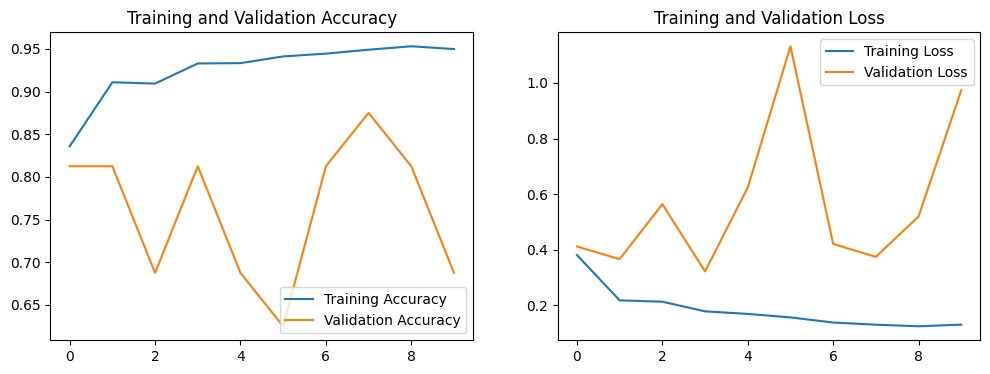

In [10]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()